# Лабораторная работа №5 «Анализ последовательностей»

In [110]:
import os
import time
from math import ceil
from collections import Counter, defaultdict
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from prefixspan import PrefixSpan

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Задание 1. Реализация AprioriAll

**AprioriAll** — это адаптация алгоритма Apriori для поиска частых **последовательностей**. В отличие от ассоциативных правил, здесь важен порядок появления наборов.

### Реализация функций AprioriAll

In [89]:
# Проверяет, является ли `pattern` подпоследовательностью `sequence_with_dates`
def is_subsequence_with_gap(pattern, sequence_with_dates, max_gap_days=None):
    def backtrack(pattern_idx, seq_idx, last_date):
        if pattern_idx == len(pattern):
            return True
        for i in range(seq_idx, len(sequence_with_dates)):
            date, itemset = sequence_with_dates[i]

            # Проверяем максимальный пробел
            if last_date is not None and max_gap_days is not None:
                if (date - last_date).days > max_gap_days:
                    return False

            if pattern[pattern_idx].issubset(itemset):
                # Пытаемся найти следующий элемент шаблона
                if backtrack(pattern_idx + 1, i + 1, date):
                    return True
        return False

    return backtrack(0, 0, None)

# Генерирует кандидатов Ck длины k из частых наборов Lk-1 длины k-1
def apriori_all_generate_candidates(Lk_minus_1, k):
    Ck = set()
    Lk_list = list(Lk_minus_1)
    for i in range(len(Lk_list)):
        for j in range(len(Lk_list)):
            seq1 = Lk_list[i]
            seq2 = Lk_list[j]

            if seq1[:-1] == seq2:
                if len(seq1[-1]) == 1 and len(seq2[-1]) == 1:
                    last_item1 = next(iter(seq1[-1]))
                    last_item2 = next(iter(seq2[-1]))
                    if last_item1 < last_item2:
                        new_last_itemset = seq1[-1].union(seq2[-1])
                        new_candidate = seq1[:-1] + (new_last_itemset,)
                        Ck.add(new_candidate)

            if k == 2 and len(seq1) == 1 and len(seq2) == 1:
                item1 = next(iter(seq1[0]))
                item2 = next(iter(seq2[0]))

                if item1 != item2:
                    Ck.add((frozenset([item1]), frozenset([item2])))
                if item1 < item2:
                    Ck.add((frozenset([item1, item2]),))

            if seq1 == seq2[:-1]:
                Ck.add(seq2)

    return list(Ck)


def apriori_all(sequences_with_dates, min_support, max_len=3, max_gap_days=None, verbose=False):
    num_sequences = len(sequences_with_dates)
    if num_sequences == 0: return {}
    min_count = ceil(min_support * num_sequences)

    # Находим частые последовательности L1
    item_counts = defaultdict(int)
    for seq_data in sequences_with_dates:
        unique_items_in_seq = set(item for _, itemset in seq_data['sequence'] for item in itemset)
        for item in unique_items_in_seq:
            item_counts[item] += 1

    L1_patterns_list = []
    all_frequent = {}
    for item, count in item_counts.items():
        if count >= min_count:
            key = (frozenset([item]),)
            all_frequent[key] = count / num_sequences
            L1_patterns_list.append(key)

    if not L1_patterns_list:
        return all_frequent

    # Ищем более длинные последовательности
    Lk_minus_1 = set(L1_patterns_list)
    k = 2
    while Lk_minus_1:
        current_len = sum(len(s) for s in next(iter(Lk_minus_1)))
        if current_len >= max_len:
            break

        Ck = apriori_all_generate_candidates(Lk_minus_1, current_len + 1)
        if not Ck: break

        candidate_counts = defaultdict(int)
        for seq_data in sequences_with_dates:
            for candidate in Ck:
                if is_subsequence_with_gap(candidate, seq_data['sequence'], max_gap_days):
                    candidate_counts[candidate] += 1

        Lk_next = set()
        for candidate, count in candidate_counts.items():
            if count >= min_count:
                support = count / num_sequences
                Lk_next.add(candidate)
                all_frequent[candidate] = support

        if not Lk_next: break

        if verbose: print(f"Найдено {len(Lk_next)} частых шаблонов длины > {current_len}")

        Lk_minus_1 = Lk_next

    return all_frequent

# Классический Apriori для наборов
def apriori_generate_candidates(Lk_minus_1):
    Ck = set()
    L = sorted(list(Lk_minus_1), key=lambda x: tuple(sorted(x)))
    for i in range(len(L)):
        for j in range(i + 1, len(L)):
            a, b = L[i], L[j]
            union = a | b
            if len(union) == len(a) + 1:
                # prune
                all_subsets_ok = True
                for subset in combinations(union, len(union) - 1):
                    if frozenset(subset) not in Lk_minus_1:
                        all_subsets_ok = False
                        break
                if all_subsets_ok:
                    Ck.add(frozenset(union))
    return list(Ck)


def apriori(transactions, min_support):
    transactions = [set(t) for t in transactions if len(t) > 0]
    num_transactions = float(len(transactions))
    if num_transactions == 0:
        return {}

    # L1
    item_counts = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            item_counts[frozenset([item])] += 1

    L1 = {
        itemset: count / num_transactions
        for itemset, count in item_counts.items()
        if (count / num_transactions) >= min_support
    }

    all_frequent_itemsets = L1.copy()
    Lk_minus_1 = set(L1.keys())

    while Lk_minus_1:
        Ck = apriori_generate_candidates(Lk_minus_1)
        if not Ck:
            break

        candidate_counts = defaultdict(int)
        for transaction in transactions:
            for candidate in Ck:
                if candidate.issubset(transaction):
                    candidate_counts[candidate] += 1

        Lk = {
            candidate: count / num_transactions
            for candidate, count in candidate_counts.items()
            if (count / num_transactions) >= min_support
        }

        if not Lk:
            break

        all_frequent_itemsets.update(Lk)
        Lk_minus_1 = set(Lk.keys())

    return all_frequent_itemsets


def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0, max_antecedent_len=None, max_consequent_len=None):
    rules = []

    for itemset, support_itemset in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        items = list(itemset)
        for i in range(1, len(items)):
            for antecedent_tuple in combinations(items, i):
                antecedent = frozenset(antecedent_tuple)
                consequent = frozenset(itemset) - antecedent

                if max_antecedent_len and len(antecedent) > max_antecedent_len:
                    continue
                if max_consequent_len and len(consequent) > max_consequent_len:
                    continue

                support_antecedent = frequent_itemsets.get(antecedent)
                support_consequent = frequent_itemsets.get(consequent)

                if support_antecedent is None or support_consequent is None:
                    continue

                confidence = support_itemset / support_antecedent
                if confidence < min_confidence:
                    continue

                lift = confidence / support_consequent
                if lift < min_lift:
                    continue

                leverage = support_itemset - (support_antecedent * support_consequent)
                conviction = (1 - support_consequent) / (1 - confidence) if confidence < 1.0 else float("inf")

                rules.append({
                    "antecedent": antecedent,
                    "consequent": consequent,
                    "support": support_itemset,
                    "confidence": confidence,
                    "lift": lift,
                    "leverage": leverage,
                    "conviction": conviction
                })

    return sorted(rules, key=lambda x: x["lift"], reverse=True)

## Задание 2. Анализ реальных данных

Загружаем датасет **Online Retail** и преобразуем его в формат последовательностей.

In [77]:
def load_and_prepare_data(path, top_n_items=40):
    df = pd.read_csv(path, encoding="ISO-8859-1")

    df.columns = [c.strip() for c in df.columns]
    df.dropna(subset=['CustomerID', 'Description'], inplace=True)
    df = df[df['Quantity'] > 0] # Возвраты
    df['Description'] = df['Description'].str.strip()
    df['CustomerID'] = df['CustomerID'].astype(int)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce').dropna()

    top_items = df["Description"].value_counts().head(top_n_items).index.tolist()
    df_filtered = df[df["Description"].isin(top_items)].copy()

    transactions_df = (df_filtered.groupby(['CustomerID', 'InvoiceNo', 'InvoiceDate']).agg(items=("Description", frozenset)).reset_index().sort_values(['CustomerID', 'InvoiceDate']))

    client_sequences = []
    for client_id, group in transactions_df.groupby('CustomerID'):
        sequence_with_dates = list(zip(group['InvoiceDate'], group['items']))
        if len(sequence_with_dates) >= 2: # Клиенты с 2+ покупками
            client_sequences.append({'client_id': client_id, 'sequence': sequence_with_dates})

    return df_filtered, client_sequences

FILEPATH = "../data/Online Retail.csv"
df_retail, client_sequences = load_and_prepare_data(FILEPATH)

print(f"Количество клиентов для анализа (с 2+ транзакциями): {len(client_sequences)}")

Количество клиентов для анализа (с 2+ транзакциями): 1635


### 2.1 Влияние минимальной поддержки

Проведем эксперимент, чтобы увидеть, как изменение порога `min_support` влияет на количество найденных последовательностей и время работы алгоритма.

Запуск AprioriAll с min_support = 5%...
  Найдено 40 шаблонов за 1.79 сек.

Запуск AprioriAll с min_support = 10%...
  Найдено 38 шаблонов за 1.59 сек.

Запуск AprioriAll с min_support = 15%...
  Найдено 9 шаблонов за 0.09 сек.

Запуск AprioriAll с min_support = 20%...
  Найдено 2 шаблонов за 0.01 сек.



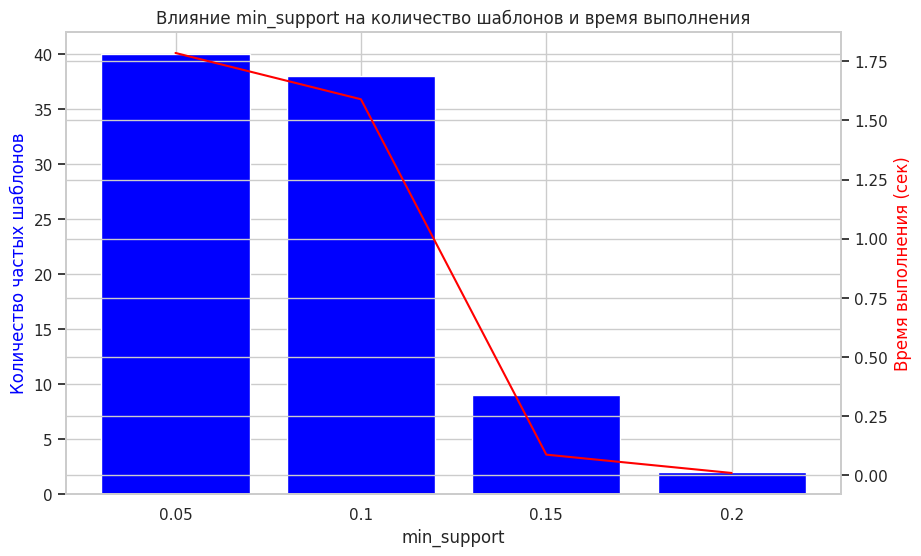

In [79]:
if 'client_sequences' in locals() and client_sequences:
    min_supports_test = [0.05, 0.10, 0.15, 0.20]
    results = []

    for ms in min_supports_test:
        print(f"Запуск AprioriAll с min_support = {ms*100:.0f}%...")
        start_time = time.time()
        patterns = apriori_all(client_sequences, min_support=ms, max_len=3, verbose=False)
        elapsed = time.time() - start_time

        results.append({'min_support': ms, 'num_patterns': len(patterns), 'time_sec': elapsed})
        print(f"  Найдено {len(patterns)} шаблонов за {elapsed:.2f} сек.\n")

    results_df = pd.DataFrame(results)

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    ax1.bar(results_df['min_support'].astype(str), results_df['num_patterns'], color='blue', label='Количество шаблонов')
    ax2.plot(results_df['min_support'].astype(str), results_df['time_sec'], color='red', label='Время (сек)')

    ax1.set_xlabel('min_support')
    ax1.set_ylabel('Количество частых шаблонов', color='blue')
    ax2.set_ylabel('Время выполнения (сек)', color='red')
    plt.title('Влияние min_support на количество шаблонов и время выполнения')
    plt.show()

    frequent_patterns_for_analysis = apriori_all(client_sequences, min_support=0.1)

График наглядно показывает работу AprioriAll:

1.  **Количество шаблонов:** С увеличением `min_support` с 5% до 20%, количество найденных частых последовательностей падает. Это происходит потому, что высокий порог отсеивает непопулярные паттерны поведения клиентов.
2.  **Время выполнения:** Время работы алгоритма также сокращается с ростом `min_support`. Это происходит потому, что при высоком пороге уже на последующих итерациях алгоритму приходится проверять всё меньше кандидатов.

### 2.2 Сравнение с ассоциативными правилами

Теперь проведем сравнение. Мы возьмем те же транзакции, но без порядка и ID клиента. Применим к ним **классический Apriori**.

In [91]:
# Сплющиваем все транзакции клиента в одну большую корзину
classic_transactions = [
    set(item for basket in seq for item in basket)
    for seq in sampled_sequences
]
classic_transactions = [t for t in classic_transactions if t]

print(f"Подготовлено {len(classic_transactions)} сплющенных транзакций для классического Apriori.")

MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.4
MIN_LIFT = 1.2

print(f"\nЗапуск классического Apriori (min_support={MIN_SUPPORT})...")
freq_itemsets = apriori(classic_transactions, MIN_SUPPORT)
print(f"Найдено {len(freq_itemsets)} частых наборов.")

if freq_itemsets:
    rules = generate_rules(freq_itemsets, min_confidence=MIN_CONFIDENCE, min_lift=MIN_LIFT)
    print(f"Сгенерировано {len(rules)} правил.")

    # Берём только правила вида {A} -> {B}
    single_rules = [
        r for r in rules
        if len(r["antecedent"]) == 1 and len(r["consequent"]) == 1
    ]

    if single_rules:
        top_3_rules = sorted(single_rules, key=lambda x: x['lift'], reverse=True)[:3]
        print("\nТоп-3 ассоциативных правила по Lift:")
        display(pd.DataFrame(top_3_rules))

        print("\nПроверка, являются ли эти правила частыми последовательностями <{A}, {B}>")
        sampled_sequences_with_dates = [{"sequence": [(i, basket) for i, basket in enumerate(seq)]} for seq in sampled_sequences]

        frequent_seqs_check = apriori_all(sampled_sequences_with_dates, MIN_SUPPORT)

        for rule in top_3_rules:
            antecedent_item = next(iter(rule["antecedent"]))
            consequent_item = next(iter(rule["consequent"]))
            seq_to_check = (frozenset([antecedent_item]), frozenset([consequent_item]))
            is_frequent = seq_to_check in frequent_seqs_check
            print(f"Правило {set(rule['antecedent'])} -> {set(rule['consequent'])}:")
            print(f"  Является ли частой последовательностью <{{A}}, {{B}}>? -> {is_frequent}")

Подготовлено 2000 сплющенных транзакций для классического Apriori.

Запуск классического Apriori (min_support=0.03)...
Найдено 192 частых наборов.
Сгенерировано 11 правил.

Топ-3 ассоциативных правила по Lift:


,antecedent,consequent,support,confidence,lift,leverage,conviction
0,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.030,0.526316,10.964912,0.027264,2.009778
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.030,0.625000,10.964912,0.027264,2.514667
2,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE),0.031,0.500000,9.433962,0.027714,1.894000



Проверка, являются ли эти правила частыми последовательностями <{A}, {B}>
Правило {'ALARM CLOCK BAKELIKE RED'} -> {'ALARM CLOCK BAKELIKE GREEN'}:
  Является ли частой последовательностью <{A}, {B}>? -> False
Правило {'ALARM CLOCK BAKELIKE GREEN'} -> {'ALARM CLOCK BAKELIKE RED'}:
  Является ли частой последовательностью <{A}, {B}>? -> False
Правило {'WOODEN PICTURE FRAME WHITE FINISH'} -> {'WOODEN FRAME ANTIQUE WHITE'}:
  Является ли частой последовательностью <{A}, {B}>? -> False


**1. Найденные ассоциативные правила:**
*   Алгоритм нашел сильные правила с высоким **Lift** (например, `10.96`), в основном между товарами одного типа, но разных цветов (`ALARM CLOCK BAKELIKE RED` и `GREEN`).
*   Это означает, что эти товары **очень часто покупают вместе, в одной корзине**.

**2. Проверка на последовательность:**
*   Проверили, покупают ли клиенты эти же товары **последовательно** (сначала один, потом в другой раз — второй).
*   Результат для всех топ-3 правил был **"False"**.

**Главный вывод:**
Сильная ассоциация **не равна** сильной последовательности. Наши данные показывают, что клиенты склонны покупать товары одной серии **сразу комплектом**, но не возвращаются за ними позже.

### 2.3 Временные окна (max_gap)

Теперь мы введем временное ограничение `max_gap_days`. Это позволит нам найти только те последовательности, где между покупками проходит не более заданного числа дней.

In [97]:
if 'client_sequences' in locals() and client_sequences:
    min_sup_gap = 0.01

    print("--- Сравнение результатов с max_gap и без ---")

    print("\nЗапуск без ограничения (max_gap = None)...")
    start_time = time.time()
    patterns_no_gap = apriori_all(client_sequences, min_support=min_sup_gap, max_gap_days=None)
    print(f"  Найдено {len(patterns_no_gap)} шаблонов за {time.time() - start_time:.2f} сек.")

    print("\nЗапуск с ограничением (max_gap = 7 дней)...")
    start_time = time.time()
    patterns_7_gap = apriori_all(client_sequences, min_support=min_sup_gap, max_gap_days=7)
    print(f"  Найдено {len(patterns_7_gap)} шаблонов за {time.time() - start_time:.2f} сек.")

    set_no_gap = set(patterns_no_gap.keys())
    set_gap_7 = set(patterns_7_gap.keys())
    disappeared_patterns = set_no_gap - set_gap_7

    print(f"\nКоличество частых последовательностей без max_gap: {len(set_no_gap)}")
    print(f"Количество частых последовательностей с max_gap=7: {len(set_gap_7)}")
    print(f"Количество исчезнувших шаблонов: {len(disappeared_patterns)}")

    disappeared_examples = [p for p in disappeared_patterns if len(p) >= 2]
    if disappeared_examples:
        print(f"\nПример исчезнувшего шаблона:")
        print(ex)

--- Сравнение результатов с max_gap и без ---

Запуск без ограничения (max_gap = None)...
  Найдено 1405 шаблонов за 7.57 сек.

Запуск с ограничением (max_gap = 7 дней)...
  Найдено 218 шаблонов за 7.29 сек.

Количество частых последовательностей без max_gap: 1405
Количество частых последовательностей с max_gap=7: 218
Количество исчезнувших шаблонов: 1187

Пример исчезнувшего шаблона:
(frozenset({'WOODEN PICTURE FRAME WHITE FINISH'}), frozenset({'SPOTTY BUNTING'}))


Введение ограничения `max_gap=7` делает условие поиска последовательностей значительно **строже**.

**Результат:**
*   Количество найденных частых шаблонов с `max_gap=7` **значительно меньше**, чем без ограничения.
*   Многие шаблоны, которые считались частыми, **исчезли**.

Это полезно для задач, где важна скорость реакции. Например, для отправки рассылки с рекомендацией или для акции "купите в течение недели и получите скидку".

### 2.4 Визуализация

Визуализируем один из найденных частых последовательных шаблонов в виде графа переходов.

Шаблон: (frozenset({'LUNCH BAG RED RETROSPOT'}), frozenset({'LUNCH BAG  BLACK SKULL.'}))
Support: 0.059


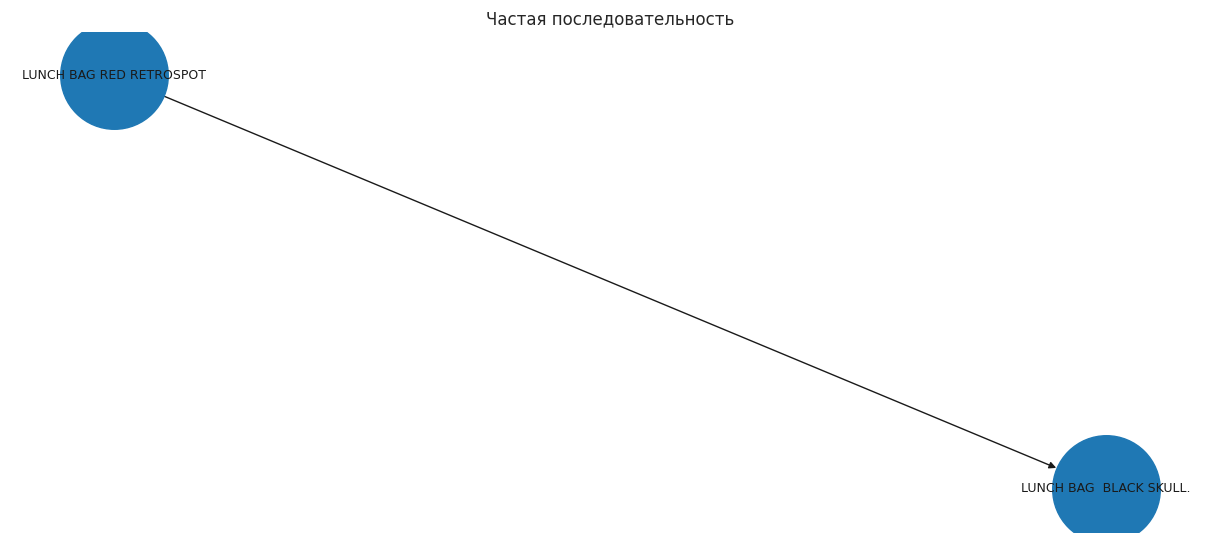

In [102]:
frequent_patterns_for_analysis = patterns_no_gap

patterns_len2_plus = {
    p: s
    for p, s in frequent_patterns_for_analysis.items()
    if len(p) >= 2
}

if not patterns_len2_plus:
    print("Частых шаблонов длины >= 2 не найдено.")
else:
    interesting_pattern, support_value = max(
        patterns_len2_plus.items(),
        key=lambda x: x[1]
    )

    print("Шаблон:", interesting_pattern)
    print(f"Support: {support_value:.3f}")

    G = nx.DiGraph()

    for i in range(len(interesting_pattern) - 1):
        source = " & ".join(sorted(interesting_pattern[i]))
        target = " & ".join(sorted(interesting_pattern[i + 1]))
        G.add_edge(source, target)

    plt.figure(figsize=(12, 5))

    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=6000,
        arrows=True,
        font_size=9
    )

    plt.title("Частая последовательность")
    plt.show()

## Задание 3. Сравнение алгоритмов SPM

Сравним нашу реализацию `AprioriAll` с готовой быстрой реализацией `PrefixSpan`.

In [113]:
if 'client_sequences' in locals() and client_sequences:
    MIN_SUPPORT_COMPARE = 0.10

    print(f"1. Запуск AprioriAll (min_support={MIN_SUPPORT_COMPARE})...")
    start_aprioriall = time.time()

    patterns_aprioriall = apriori_all(
        client_sequences,
        min_support=MIN_SUPPORT_COMPARE
    )

    time_aprioriall = time.time() - start_aprioriall

    print(f"2. Запуск PrefixSpan (min_support={MIN_SUPPORT_COMPARE})...")

    sequences_for_ps = []

    for client in client_sequences:
        seq = []

        for _, basket in client['sequence']:
            basket_label = " | ".join(sorted(basket))
            seq.append(basket_label)

        sequences_for_ps.append(seq)

    min_count_compare = ceil(
        MIN_SUPPORT_COMPARE * len(sequences_for_ps)
    )

    start_prefixspan = time.time()

    ps = PrefixSpan(sequences_for_ps)
    patterns_ps = ps.frequent(min_count_compare)

    time_prefixspan = time.time() - start_prefixspan

    comparison_df = pd.DataFrame([
        {
            'Алгоритм': 'AprioriAll',
            'Время (сек)': round(time_aprioriall, 4),
            'Кол-во шаблонов': len(patterns_aprioriall)
        },
        {
            'Алгоритм': 'PrefixSpan',
            'Время (сек)': round(time_prefixspan, 4),
            'Кол-во шаблонов': len(patterns_ps)
        }
    ])

    print("\n--- Сравнительная таблица производительности ---")
    display(comparison_df)

else:
    print("client_sequences не найдены.")

1. Запуск AprioriAll (min_support=0.1)...
2. Запуск PrefixSpan (min_support=0.1)...

--- Сравнительная таблица производительности ---


,Алгоритм,Время (сек),Кол-во шаблонов
0,AprioriAll,6.1952,38
1,PrefixSpan,0.0057,1


**Анализ результатов**

*   Время выполнения. Библиотечная реализация PrefixSpan оказалась значительно быстрее AprioriAll (0.0057 с против 6.1952 с). Это связано с тем, что PrefixSpan использует стратегию проекции префиксов и не генерирует большое количество кандидатов.
*   Количество найденных шаблонов. AprioriAll обнаружил 38 частых последовательностей, тогда как PrefixSpan нашёл только 1 шаблон. Такое различие связано с различиями в формате представления данных для PrefixSpan и AprioriAll при проведении эксперимента, поэтому результаты по количеству шаблонов напрямую сравнивать нельзя.

*   Вывод. По времени выполнения PrefixSpan существенно превосходит AprioriAll.

## Задание 4. Предсказание следующего события

Построим простую модель рекомендации на основе найденных последовательностей.

In [117]:
if 'client_sequences' in locals() and client_sequences:
    # Разделяем данные на обучающую и тестовую выборки
    train_clients, test_cases = [], []
    for client in client_sequences:
        seq_with_dates = client['sequence']
        if len(seq_with_dates) < 2: continue

        split_idx = max(1, int(len(seq_with_dates) * 0.8))
        if split_idx >= len(seq_with_dates): continue

        train_clients.append({'client_id': client['client_id'], 'sequence': seq_with_dates[:split_idx]})

        test_cases.append({
            'context': seq_with_dates[split_idx - 1][1], # Набор товаров из последней покупки
            'actual_next': seq_with_dates[split_idx][1]   # Набор товаров из следующей покупки
        })

    print(f"Данные разделены: {len(train_clients)} клиентов в train, {len(test_cases)} случаев для теста.")

    # Строим модель на обучающих данных
    frequent_patterns_train = apriori_all(train_clients, min_support=0.03, max_len=2)

    # Создаем простую рекомендательную карту
    recommendation_map = defaultdict(list)
    for pat, support in frequent_patterns_train.items():
        if len(pat) == 2 and len(pat[0]) == 1 and len(pat[1]) == 1:
            prev_item = next(iter(pat[0]))
            next_item = next(iter(pat[1]))
            recommendation_map[prev_item].append((next_item, support))

    # Для каждого товара оставляем только лучшую рекомендацию
    best_next_item = {
        item: max(preds, key=lambda x: x[1])[0] for item, preds in recommendation_map.items() if preds
    }

    # Определяем базовый подход
    all_train_items = [item for client in train_clients for _, items in client['sequence'] for item in items]
    global_top_item = Counter(all_train_items).most_common(1)[0][0] if all_train_items else None
    print(f"Базовый подход (всегда рекомендовать самый частый товар): '{global_top_item}'")

    # Оценка точности
    correct_seq, correct_base, total = 0, 0, len(test_cases)
    for case in test_cases:
        # Генерируем предсказания для каждого товара
        predicted_items = {best_next_item.get(item, global_top_item) for item in case['context']}

        if predicted_items & case['actual_next']:
            correct_seq += 1

        if global_top_item in case['actual_next']:
            correct_base += 1

    accuracy_seq = correct_seq / total if total > 0 else 0
    accuracy_base = correct_base / total if total > 0 else 0

    print("\n--- Результаты оценки точности (accuracy@1) ---")
    display(pd.DataFrame([{'Модель': 'Последовательная', 'Точность': accuracy_seq}, {'Модель': 'Базовая (топ-товар)', 'Точность': accuracy_base}]))

Данные разделены: 1635 клиентов в train, 1635 случаев для теста.
Базовый подход (всегда рекомендовать самый частый товар): 'WHITE HANGING HEART T-LIGHT HOLDER'

--- Результаты оценки точности (accuracy@1) ---


,Модель,Точность
0,Последовательная,0.118654
1,Базовая (топ-товар),0.083792


### Анализ вывода

Последовательная модель показывает более высокую точность (0.119), чем базовый подход (0.084). Это означает, что учёт предыдущих покупок действительно улучшает предсказание следующего товара.

### Вывод

Учёт последовательности улучшает качество рекомендаций, но модель остаётся простой и имеет ограниченную точность.

## Задание 5. Контрастные последовательности

**Бизнес-задача:** Найти последовательности покупок, которые **характерны для "хороших" клиентов**, но **не характерны для "обычных"**.

In [123]:
if 'df_retail' in locals() and df_retail is not None:

    if "Quantity" in df_retail.columns and "UnitPrice" in df_retail.columns:
        df_retail['TotalPrice'] = df_retail['Quantity'] * df_retail['UnitPrice']
        customer_revenue = df_retail.groupby('CustomerID')['TotalPrice'].sum()
    else:
        customer_revenue = df_retail.groupby('CustomerID').size()

    revenue_threshold = customer_revenue.quantile(0.75)
    high_value_customers = set(customer_revenue[customer_revenue >= revenue_threshold].index)

    seqs_high = [c for c in client_sequences if c['client_id'] in high_value_customers]
    seqs_low = [c for c in client_sequences if c['client_id'] not in high_value_customers]

    print(f"Порог для High Value: > {revenue_threshold:.2f}")
    print(f"High Value клиентов в выборке: {len(seqs_high)}")
    print(f"Low Value клиентов в выборке: {len(seqs_low)}")

    MIN_SUP_CONTRAST = 0.08

    print("\nПоиск паттернов для High Value клиентов...")
    patterns_high = apriori_all(seqs_high, min_support=MIN_SUP_CONTRAST, max_len=2)

    print("Поиск паттернов для Low Value клиентов...")
    patterns_low = apriori_all(seqs_low, min_support=MIN_SUP_CONTRAST, max_len=2)

    print(f"  High Value паттернов: {len(patterns_high)}")
    print(f"  Low Value паттернов: {len(patterns_low)}")

    contrast_results = []
    all_pats = set(patterns_high.keys()) | set(patterns_low.keys())

    for pat in all_pats:
        sup_high = patterns_high.get(pat, 0.0)
        sup_low = patterns_low.get(pat, 0.0)

        if sup_high > sup_low:
            pattern_str = " -> ".join(
                ["{" + ", ".join(sorted(list(s))) + "}" for s in pat]
            )

            contrast_results.append({
                "pattern": pattern_str,
                "support_high": sup_high,
                "support_low": sup_low,
                "contrast": sup_high - sup_low
            })

    if contrast_results:
        contrast_df = pd.DataFrame(contrast_results).sort_values("contrast", ascending=False)

        print("\n--- Топ-5 последовательностей для High Value клиентов ---")
        display(contrast_df.head(5))

        top = contrast_df.iloc[0]

        print("\nБизнес-гипотеза:")
        print(
            f"Паттерн {top['pattern']} встречается у "
            f"{top['support_high']:.1%} High Value и "
            f"{top['support_low']:.1%} Low Value клиентов. "
            "Это маркер более ценных клиентов."
        )

Порог для High Value: > 136.02
High Value клиентов в выборке: 697
Low Value клиентов в выборке: 938

Поиск паттернов для High Value клиентов...
Поиск паттернов для Low Value клиентов...
  High Value паттернов: 88
  Low Value паттернов: 30

--- Топ-5 последовательностей для High Value клиентов ---


,pattern,support_high,support_low,contrast
64,{LUNCH BAG APPLE DESIGN},0.203730,0.00000,0.203730
3,{LUNCH BAG WOODLAND},0.197991,0.00000,0.197991
40,{ALARM CLOCK BAKELIKE RED},0.197991,0.00000,0.197991
86,{JUMBO BAG PINK POLKADOT},0.193687,0.00000,0.193687
71,{JUMBO BAG RED RETROSPOT},0.304161,0.11194,0.192220



Бизнес-гипотеза:
Паттерн {LUNCH BAG APPLE DESIGN} встречается у 20.4% High Value и 0.0% Low Value клиентов. Это маркер более ценных клиентов.


### Анализ вывода:

В этом задании мы сравнили поведение High Value и Low Value клиентов и нашли паттерны, которые различают эти группы.

**Результаты:**
* Было выделено 88 частых паттернов у High Value клиентов и 30 у Low Value клиентов.
* В топе контрастных паттернов доминируют отдельные товары (по сути, частые одиночные покупки), а не сложные последовательности.
* Это связано с тем, что ограничение `max_len=2` сильно упрощает структуру паттернов - большинство результатов являются наборами из одного товара.

**Вывод:**
Видны сильный различия между сегментами клиентов, анализ выявляет в основном популярность товаров, а не сложные последовательные паттерны поведения.